# 图表反演

In [29]:
import matplotlib.pyplot as plt
# 设置中文字体支持
import matplotlib.font_manager as fm
# 备选中文字体列表
chinese_fonts = [
    "SimHei",           # Windows
    "Heiti TC",         # macOS
    "WenQuanYi Micro Hei",  # Linux
    "Microsoft YaHei",  # 微软雅黑
    "Arial Unicode MS", # 备选
]

# 获取系统可用字体
available_fonts = {f.name for f in fm.fontManager.ttflist}

# 查找第一个可用的中文字体
for font in chinese_fonts:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break

plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

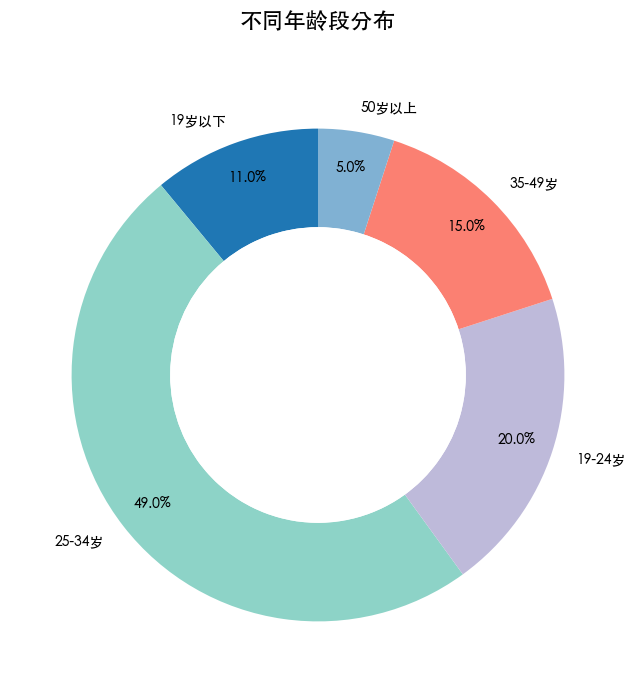

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
age_groups = ["19岁以下", "25-34岁", "19-24岁", "35-49岁", "50岁以上"]
percentages = [11, 49, 20, 15, 5]  
colors = ["#1f77b4", "#8dd3c7", "#bebada", "#fb8072", "#80b1d3"]  # 自定义颜色，可调整

# 创建环形图
fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(
    percentages,
    labels=age_groups,
    autopct="%1.1f%%",  # 显示百分比格式
    startangle=90,
    colors=colors,
    pctdistance=0.85,  # 百分比标签距离圆心的距离
    wedgeprops={"width": 0.4},  # 环形宽度
)

# 添加中心圆（让环形更明显）
centre_circle = plt.Circle((0, 0), 0.6, color="black", fc="white", linewidth=0)
ax.add_artist(centre_circle)

# 设置标题
ax.set_title("不同年龄段分布", fontsize=16, y=1.05)

# 显示图表
plt.show()

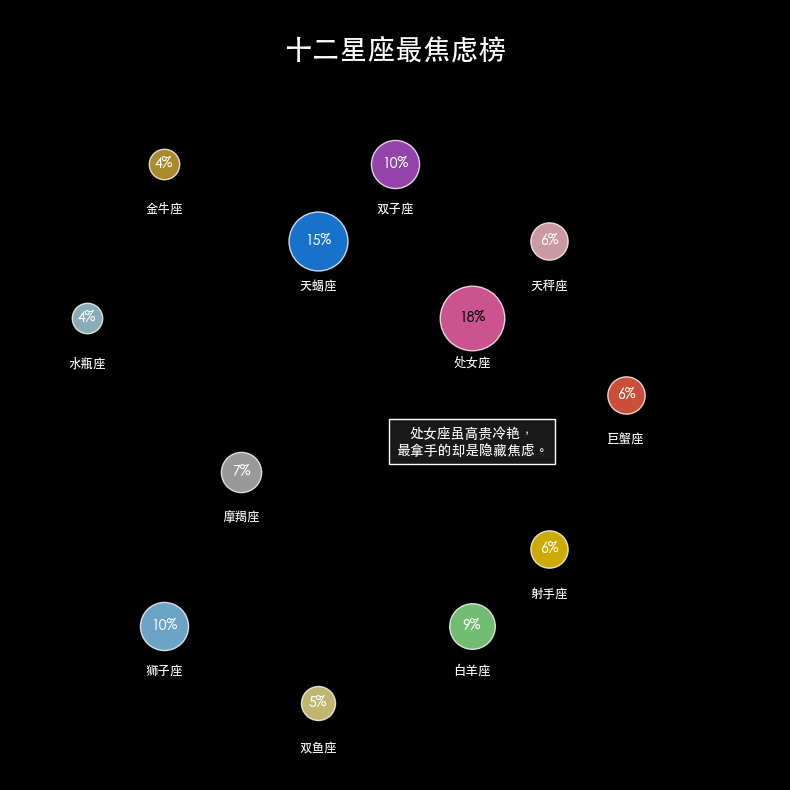

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# 数据准备
constellations = [
    "金牛座", "水瓶座", "摩羯座", "狮子座", "双鱼座", "白羊座", "射手座", "巨蟹座",
    "天秤座", "双子座", "处女座", "天蝎座"
]
percentages = [4, 4, 7, 10, 5, 9, 6, 6, 6, 10, 18, 15]
# 为方便布局，手动设置各星座坐标（可根据设计微调）
coords = [
    (0.2, 0.8), (0.1, 0.6), (0.3, 0.4), (0.2, 0.2), (0.4, 0.1), (0.6, 0.2),
    (0.7, 0.3), (0.8, 0.5), (0.7, 0.7), (0.5, 0.8), (0.6, 0.6), (0.4, 0.7)
]
# 对应气泡颜色（示例配色，可自行调整）
colors = [
    "#D4AF37", "#ADD8E6", "#C0C0C0", "#87CEFA", "#F0E68C", "#90EE90",
    "#FFD700", "#FF6347", "#FFC0CB", "#BA55D3", "#FF69B4", "#1E90FF"
]
# 处女座特殊标注文本
virgo_text = "处女座虽高贵冷艳，\n最拿手的却是隐藏焦虑。"

# 创建画布
fig, ax = plt.subplots(figsize=(8, 8), facecolor='black')
ax.set_facecolor('black')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
# 隐藏坐标轴
ax.set_xticks([])
ax.set_yticks([])

# 绘制气泡 + 标注
for constellation, p, (x, y), color in zip(constellations, percentages, coords, colors):
    # 绘制气泡（散点图模拟）
    ax.scatter(
        x, y, 
        s=p * 120,  # 气泡大小与焦虑占比关联
        c=color, 
        alpha=0.8,
        edgecolors='white', 
        linewidths=1
    )
    # 绘制百分比文本
    text_color = 'white' if p != 18 else 'black'  # 处女座文本反色
    ax.text(
        x, y, 
        f"{p}%", 
        ha='center', 
        va='center', 
        fontsize=10, 
        color=text_color, 
        fontweight='bold'
    )
    # 绘制星座名称
    ax.text(
        x, y - 0.05, 
        constellation, 
        ha='center', 
        va='top', 
        fontsize=9, 
        color='white'
    )

# 处女座特殊说明文本
virgo_x, virgo_y = coords[constellations.index("处女座")]
ax.text(
    virgo_x, virgo_y - 0.18, 
    virgo_text, 
    ha='center', 
    va='bottom', 
    fontsize=10, 
    color='white', 
    linespacing=1.2,
    # 修复：将CSS颜色格式改为RGBA元组格式
    bbox=dict(facecolor=(1, 1, 1, 0.1), edgecolor='white', pad=5)
)

# 添加标题
ax.text(
    0.5, 0.95, 
    "十二星座最焦虑榜", 
    ha='center', 
    va='center', 
    fontsize=20, 
    color='white', 
    fontweight='bold'
)

plt.tight_layout()
plt.show()    

/var/folders/54/bbrbnf8953d7z0fzwhskm0b00000gn/T/ipykernel_17853/3522357574.py:85: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=cm.get_cmap('Blues_r'), alpha=0.3


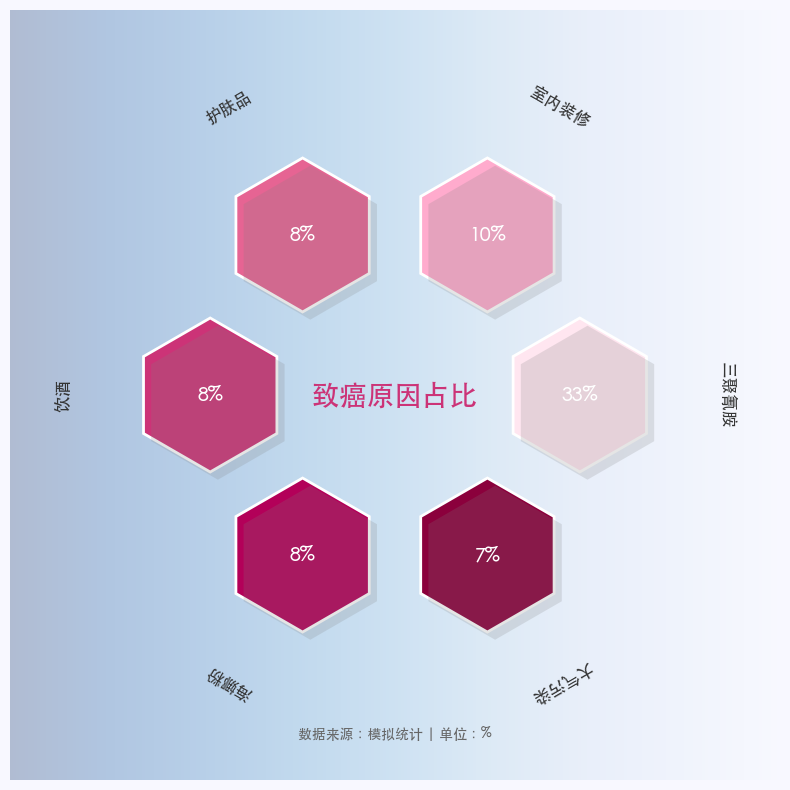

In [32]:
import matplotlib.pyplot as plt
from matplotlib.patches import RegularPolygon
import numpy as np
from matplotlib import cm
from matplotlib.colors import LinearSegmentedColormap

# ======================== 1. 数据与基础配置 ========================
labels = ["三聚氰胺", "室内装修", "护肤品", "饮酒", "海娜粉", "大气污染"]
sizes = [33, 10, 8, 8, 8, 7]

# 六边形环形分布坐标（极坐标转直角坐标）
theta = np.linspace(0, 2 * np.pi, len(labels), endpoint=False)
radius = 1.2  # 控制六边形环半径
x = radius * np.cos(theta)
y = radius * np.sin(theta)

# 自定义渐变色盘（从浅粉到深粉）
cmap = LinearSegmentedColormap.from_list(
    'pink_cmap', 
    ['#FFE6F0', '#FFABCD', '#E66493', '#CC3377', '#B30059', '#8B003C'],
    N=len(labels)
)

# ======================== 2. 初始化画布与轴 ========================
fig, ax = plt.subplots(figsize=(8, 8), facecolor='#F8F8FF')  # 浅蓝背景
ax.set_aspect('equal')
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-2.5, 2.5)
ax.axis('off')  # 隐藏坐标轴

# ======================== 3. 绘制立体六边形（带阴影+渐变） ========================
for i in range(len(labels)):
    # 主六边形（渐变填充）
    hex_main = RegularPolygon(
        (x[i], y[i]), numVertices=6, radius=0.5, 
        facecolor=cmap(i), edgecolor='white', linewidth=2
    )
    ax.add_patch(hex_main)
    
    # 阴影六边形（模拟立体效果）
    hex_shadow = RegularPolygon(
        (x[i] + 0.05, y[i] - 0.05), numVertices=6, radius=0.5, 
        facecolor='gray', alpha=0.2, edgecolor='none'
    )
    ax.add_patch(hex_shadow)
    
    # 绘制占比数字（居中，加粗）
    ax.text(
        x[i], y[i], f"{sizes[i]}%", 
        ha='center', va='center', 
        fontsize=14, fontweight='bold', 
        color='white'
    )
    
    # 绘制标签文字（环绕布局，调整角度）
    text_angle = np.rad2deg(theta[i]) - 90  # 文字角度适配六边形
    ax.text(
        x[i] * 1.8, y[i] * 1.8, labels[i], 
        ha='center', va='center', 
        fontsize=12, color='#333333', 
        rotation=text_angle
    )

# ======================== 4. 添加标题与装饰 ========================
# 中心标题
ax.text(
    0, 0, "致癌原因占比", 
    ha='center', va='center', 
    fontsize=20, fontweight='bold', 
    color='#CC3377'
)

# 底部说明
ax.text(
    0, -2.2, "数据来源：模拟统计 | 单位：%", 
    ha='center', va='center', 
    fontsize=10, color='#666666', 
)

# 渐变背景（从中心向外扩散）
gradient = np.linspace(0, 1, 256).reshape(1, -1)
gradient_img = np.tile(gradient, (256, 1))
ax.imshow(
    gradient_img, extent=(-2.5, 2.5, -2.5, 2.5), 
    cmap=cm.get_cmap('Blues_r'), alpha=0.3
)

plt.tight_layout()
plt.show()

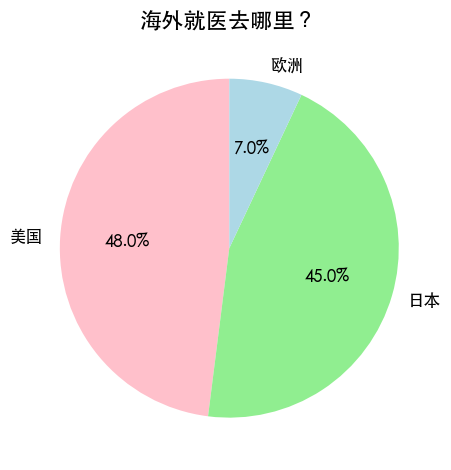

In [33]:
import matplotlib.pyplot as plt

# 数据
countries = ["美国", "日本", "欧洲"]
percentages = [48, 45, 7]  
colors = ["pink", "lightgreen", "lightblue"]  

# 创建饼图
plt.pie(
    percentages, 
    labels=countries, 
    colors=colors, 
    autopct="%1.1f%%",  # 显示百分比
    startangle=90,      # 起始角度
    textprops={"fontsize": 12}
)

# 添加标题
plt.title("海外就医去哪里？", fontsize=16, fontweight="bold")

# 调整布局（避免标签挤压）
plt.tight_layout()

# 显示图表
plt.show()

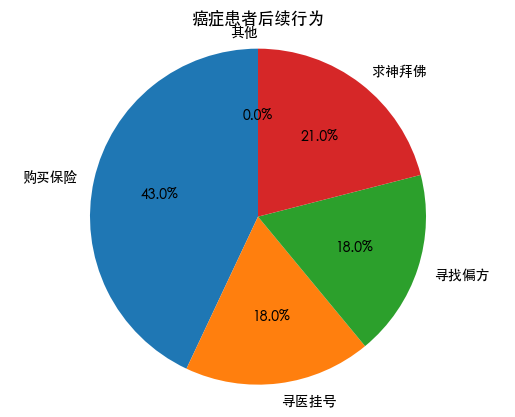

In [34]:
import matplotlib.pyplot as plt

# 数据
labels = ['购买保险', '寻医挂号', '寻找偏方', '求神拜佛', '其他']  # 这里补充“其他”，因原图表各部分占比和为43%+18%+18%+21% = 100% ，实际按你的需求调整
sizes = [43, 18, 18, 21, 0]  # 各部分占比，和为100，可按需调整
colors = ['#FFA07A', '#90EE90', '#FFC0CB', '#87CEFA', '#D3D3D3']  # 各部分颜色，可自定义

# 绘制饼图
fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
ax.axis('equal')  # 保证饼图是正圆形

# 添加标题
plt.title('癌症患者后续行为')

# 显示图表
plt.show()

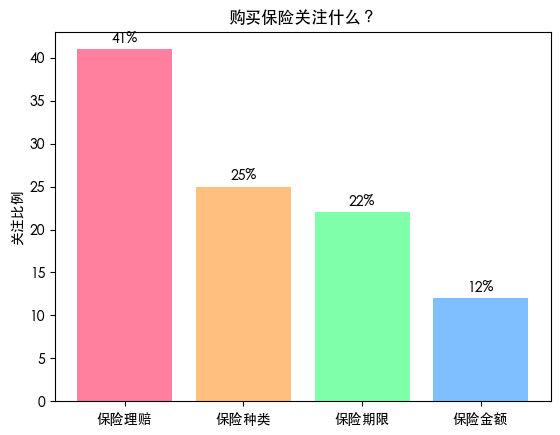

In [35]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
labels = ['保险理赔', '保险种类', '保险期限', '保险金额']
values = [41, 25, 22, 12]
colors = ['#ff7f9f', '#ffbf7f', '#7fffaa', '#7fbfff']  # 对应颜色

x = np.arange(len(labels))  # x轴位置

fig, ax = plt.subplots()
rects = ax.bar(x, values, color=colors)

# 添加数值标签
for rect in rects:
    height = rect.get_height()
    ax.annotate('{}%'.format(height),
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),  # 标签位置偏移
                textcoords="offset points",
                ha='center', va='bottom')

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('关注比例')
ax.set_title('购买保险关注什么？')

plt.show()